In [1]:
import numpy as np

import pandas as pd

import plotly.express as px
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)


In [9]:

data = {
    "Order_ID": np.arange(1, 21), 
    
    "Region": ["North", "South", "East", "West"] * 5,
    
    "Category": ["Electronics", "Clothing", "Furniture", "Electronics", "Clothing"] * 4,
    
    "Sales": np.random.randint(5000, 20000, 20),
    
    "Profit": np.random.randint(500, 5000, 20),
    
    "Quantity": np.random.randint(1, 10, 20)
}
df = pd.DataFrame(data)
df.head()

,Order_ID,Region,Category,Sales,Profit,Quantity
0,1,North,Electronics,13564,4192,6
1,2,South,Clothing,19658,3116,5
2,3,East,Furniture,16721,1824,9
3,4,West,Electronics,8290,1339,3
4,5,North,Clothing,9354,1577,6


In [10]:
df.shape
df.columns
df.describe
df.isnull().sum()

Order_ID    0
Region      0
Category    0
Sales       0
Profit      0
Quantity    0
dtype: int64

In [11]:
region_sales = df.groupby("Region")["Sales"].sum().reset_index()
region_sales

,Region,Sales
0,East,66182
1,North,64767
2,South,81368
3,West,53137


In [12]:
category_profit = df.groupby("Category")["Profit"].sum().reset_index()
category_profit

,Category,Profit
0,Clothing,22693
1,Electronics,24101
2,Furniture,13225


In [13]:
top_sales = df.sort_values(by="Sales", ascending=False).head(5)
top_sales

,Order_ID,Region,Category,Sales,Profit,Quantity
1,2,South,Clothing,19658,3116,5
12,13,North,Furniture,19395,4948,8
9,10,South,Clothing,19330,3561,2
5,6,South,Electronics,18065,1500,8
14,15,East,Clothing,17977,3021,5


In [14]:
df["Profit_Ratio"] = df["Profit"] / df["Sales"]
df

,Order_ID,Region,Category,Sales,Profit,Quantity,Profit_Ratio
0,1,North,Electronics,13564,4192,6,0.309053
1,2,South,Clothing,19658,3116,5,0.158511
2,3,East,Furniture,16721,1824,9,0.109084
3,4,West,Electronics,8290,1339,3,0.161520
4,5,North,Clothing,9354,1577,6,0.168591
5,6,South,Electronics,18065,1500,8,0.083033
6,7,East,Clothing,10903,2868,8,0.263047
7,8,West,Furniture,15953,4221,9,0.264590
8,9,North,Electronics,8110,1570,7,0.193588
9,10,South,Clothing,19330,3561,2,0.184221


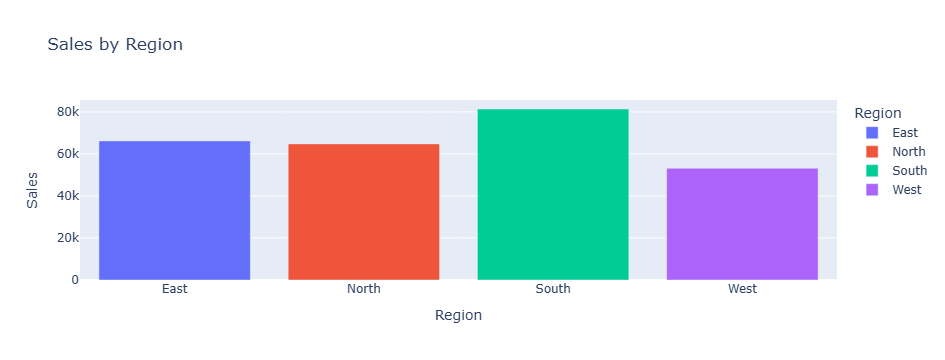

In [16]:
fig1 = px.bar(region_sales, 
              x="Region", 
              y="Sales", 
              title="Sales by Region",
              color="Region")
fig1.show()

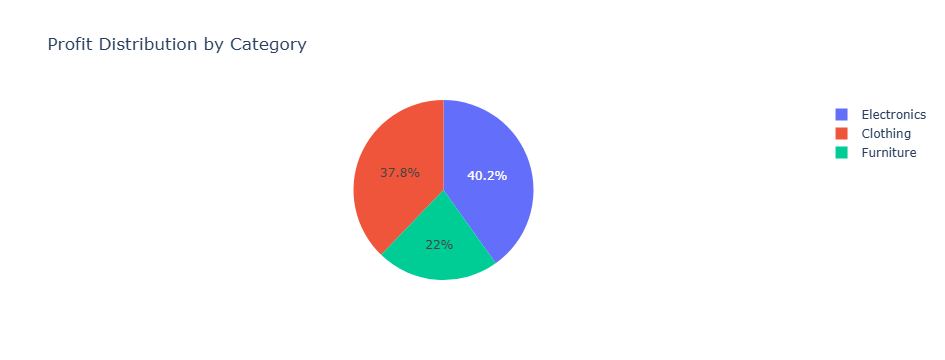

In [17]:
fig2 = px.pie(category_profit, 
              names="Category", 
              values="Profit", 
              title="Profit Distribution by Category")
fig2.show()

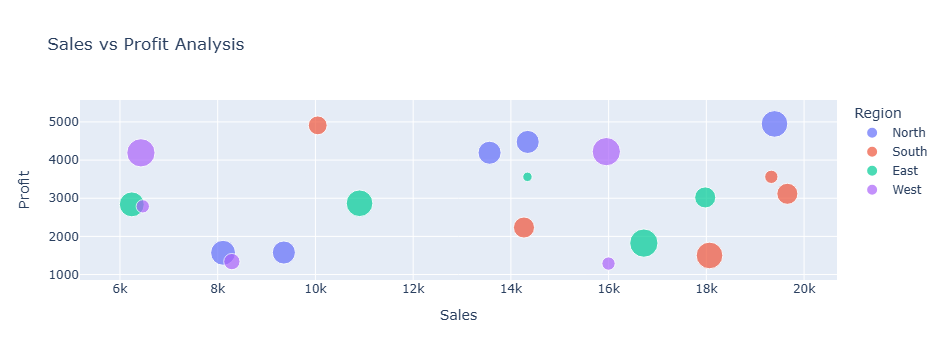

In [19]:
fig3 = px.scatter(df, 
                  x="Sales", 
                  y="Profit", 
                  color="Region",
                  size="Quantity",
                  title="Sales vs Profit Analysis")

fig3.show()

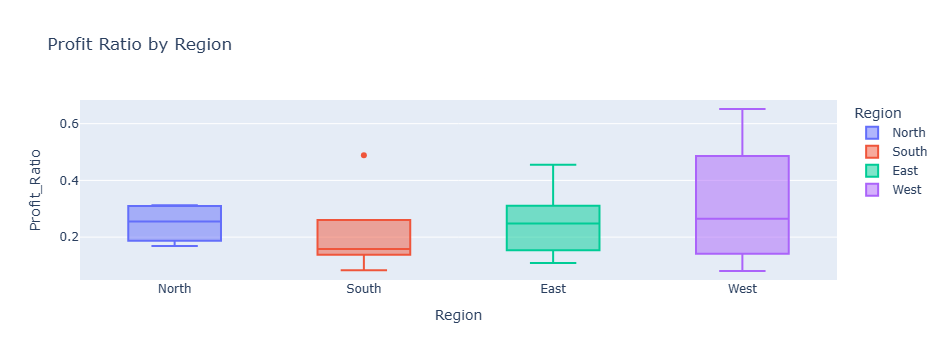

In [20]:
fig4 = px.box(df, 
              x="Region", 
              y="Profit_Ratio", 
              color="Region",
              title="Profit Ratio by Region")


fig4.show()
